# 🧠 RL & Reasoning Models

[Sam Foreman](https://samforeman.me)
(\[[ALCF](https://alcf.anl.gov/about/people/sam-foreman)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
2026-07-22

> **Authors**
>
> Written by [Sam Foreman](https://samforeman.me) for the [Intro to HPC
> Bootcamp](https://intro-hpc-bootcamp.alcf.anl.gov/).

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/03-advanced-llms/4-rl-and-reasoning/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/content/03-advanced-llms/4-rl-and-reasoning/index.qmd)

In [\[3.3\] Mid- & Post-Training](../3-mid-post-training/index.qmd) you
turned a **base model** into an instruction-follower with supervised
fine-tuning (SFT). SFT is *imitation*: it copies reference completions
token-for-token. But the best answer is often not in your dataset, and
“good” is hard to write down as a single target string. **Reinforcement
learning** takes over here: instead of imitating a fixed answer, we let
the model *generate*, **score** each generation, and push the policy
toward the high-scoring behavior — either what humans **prefer**, or
what a verifier can **prove correct**.

That second idea — reward = a programmatic check — is what powers
today’s **reasoning models** (DeepSeek-R1, o1-style): reward correct
final answers and, remarkably, an explicit chain-of-thought *emerges on
its own*. This lab builds to it via a runnable toy GRPO loop, the
algorithm family (PPO / DPO / GRPO / RLVR), and the `<think>` recipe.

> **Render note**
>
> `trl`, `peft`, and `vllm` are **not** installed in the site build
> environment, and real RL fine-tuning of a large model needs a GPU.
> Every cell that touches them is marked `#| eval: false`, so it renders
> as copy-pasteable code without running. Everything in **§① A toy that
> really runs** and the **self-consistency** section *does* run at build
> time on CPU with plain `torch` — including the real char-GPT GRPO
> training loop below, whose reward curve and before/after samples are
> computed fresh each render. Drop the `eval: false` cells on the
> cluster to run them for real.

## 🧪 ① A toy that really runs

### (a) GRPO / RLVR from scratch, in plain PyTorch

Underneath the tooling, GRPO is short. The essence of **Group Relative
Policy Optimization** ([Shao et al. 2024,
arXiv:2402.03300](https://arxiv.org/abs/2402.03300)) is:

1.  For **one prompt**, sample a **group** of $K$ completions from the
    policy.
2.  Score each with a **verifiable reward** — no learned reward model,
    just a checker (RLVR: *RL from Verifiable Rewards*).
3.  Standardize the rewards *within the group* to get an **advantage**:
    better-than- average completions get positive advantage,
    worse-than-average get negative.
4.  Nudge the policy with a **policy gradient** — raise the probability
    of the good completions, lower the probability of the bad ones.

To make this concrete we’ll train a **real (tiny) GPT** with a **real
GRPO loop** — no `trl`, no pre-canned scores, no big model. The policy
is a small Transformer that generates actual token sequences; the reward
is a Python verifier that reads those tokens. It runs on a **laptop
CPU** in well under a minute, and you can watch it genuinely learn.

**The task (a verifiable one).** The vocabulary is the ten digits `0–9`
plus a `BOS` start token. Starting from `BOS`, the model emits `L = 4`
digits, and the **reward is 1.0 if they sum to 10, else 0.0** — a cheap,
exact check with *many* valid solutions (`5 5`, `1 2 3 4`, `9 1 0 0`,
…). No labels, no reward model.

In [2]:
import os
os.environ["EZPZ_LOG_SHOW_PATH"] = "0"
import torch
import torch.nn as nn
import torch.nn.functional as F
import ezpz

logger = ezpz.get_logger(__name__)
torch.manual_seed(0)

VOCAB_SIZE, BOS, SEQ_LEN = 11, 10, 4   # tokens 0-9 are digits, token 10 = BOS

def reward(seq: list[int]) -> float:
    """Verifiable reward: 1.0 if the generated digits sum to 10, else 0.0."""
    return 1.0 if sum(seq) == 10 else 0.0

**The policy — a real, tiny GPT.** One causal Transformer block over the
digit vocabulary. Small, but a genuine autoregressive neural network
(not a lookup table):

In [3]:
class TinyGPT(nn.Module):
    def __init__(self, vocab=VOCAB_SIZE, d=64, n_head=4, block=SEQ_LEN + 1):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Embedding(block, d)
        self.block = nn.TransformerEncoderLayer(d, n_head, 2 * d,
                                                batch_first=True, dropout=0.0)
        self.ln = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab)

    def forward(self, idx):                        # idx: (B, T)
        T = idx.shape[1]
        x = self.tok(idx) + self.pos(torch.arange(T, device=idx.device))
        causal = torch.triu(torch.full((T, T), float("-inf"), device=idx.device), 1)
        return self.head(self.ln(self.block(x, src_mask=causal)))   # (B, T, vocab)


def sample_group(model, K):
    """Roll out K sequences autoregressively; return them + summed log-probs."""
    seqs = torch.full((K, 1), BOS)
    logp = torch.zeros(K)
    for _ in range(SEQ_LEN):
        logits = model(seqs)[:, -1].clone()
        logits[:, BOS] = float("-inf")            # never emit BOS mid-sequence
        dist = torch.distributions.Categorical(logits=logits)
        a = dist.sample()
        logp = logp + dist.log_prob(a)
        seqs = torch.cat([seqs, a[:, None]], dim=1)
    return seqs[:, 1:], logp                       # drop the BOS column

**The GRPO loop.** Exactly the four steps above — sample a group of `K`,
score each with the verifier, standardize rewards *within the group* for
the advantage, and take a policy-gradient step:

In [4]:
model = TinyGPT()
opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
K = 32                                             # group size (completions/step)

# generations from the UNtrained policy, for a before/after comparison
with torch.no_grad():
    before, _ = sample_group(model, 6)

reward_curve = []
for step in range(120):
    gen, logp = sample_group(model, K)             # 1. sample a group of K
    r = torch.tensor([reward(g) for g in gen.tolist()])   # 2. verifiable reward
    adv = (r - r.mean()) / (r.std() + 1e-8)        # 3. group-relative advantage
    loss = -(adv * logp).mean()                    # 4. policy gradient
    opt.zero_grad(); loss.backward(); opt.step()
    reward_curve.append(r.mean().item())
    if step % 20 == 0:
        logger.info(f"step {step:>3d}  mean reward = {r.mean():.3f}")

logger.info(f"final mean reward = {reward_curve[-1]:.3f}")

The reward climbs from near-zero (random digits rarely sum to 10) toward
1.0 as the policy learns — purely from the verifier’s 0/1 signal:

In [5]:
import plotly.graph_objects as go
from bootcamp.plotly_theme import apply_theme, COLORS
apply_theme()

fig = go.Figure(go.Scatter(y=reward_curve, mode="lines",
                           line=dict(color=COLORS["green"], width=2)))
fig.update_layout(height=320, margin=dict(t=40),
                  title="GRPO reward over training",
                  xaxis_title="step", yaxis_title="mean reward (frac summing to 10)",
                  yaxis_range=[0, 1.05])
fig.show()

Sampling from the policy **before vs. after** training makes the
learning concrete — random digits become digits that actually satisfy
the rule:

In [6]:
with torch.no_grad():
    after, _ = sample_group(model, 6)

def show(tag, seqs):
    for g in seqs.tolist():
        s = sum(g)
        logger.info(f"  {tag}: {''.join(map(str, g))}  (sum={s}, {'✓' if s == 10 else '✗'})")

show("before", before)
show("after ", after)

A few things worth noticing, because they carry over exactly to a
full-scale run:

- **No reward model.** `reward()` is a Python function. RLVR replaces a
  learned, fallible reward model with a cheap, exact check.
- **The group is the baseline.** Subtracting `r.mean()` is a
  *variance-reduction* baseline computed from the group itself — that is
  the “group relative” in GRPO, and why it needs **no value network**
  (unlike PPO).
- **Zero-variance groups give zero signal.** If all `K` samples get the
  same reward, `adv` is all zeros and nothing updates — the model
  already agrees with the group, so there is nothing to learn from it.

> **⚠️ Reward maximization collapses diversity**
>
> Look at the “after” samples: the policy tends to converge on **one**
> sum-to-10 string and emit it over and over, even though many valid
> answers exist. That’s **reward hacking / mode collapse** — nothing in
> a pure reward objective rewards *variety*, so the policy piles all its
> mass on whatever it found first.
>
> Real GRPO/PPO counter this with a **KL penalty to a frozen reference
> policy** (the same `beta` knob you’ll see in DPO below) or an
> **entropy bonus**, keeping the trained model close to the base model’s
> distribution — exactly what the production trainers in the next
> section do. The very next subsection **adds that term and watches
> diversity return**.

### (a′) Add an entropy bonus — watch diversity come back

Let’s actually fix the collapse. The cleanest knob here is an **entropy
bonus**: reward the policy for keeping its per-step distribution *spread
out*, not just for being correct. One extra term in the loss:

$$\mathcal{L} = \underbrace{-\,\mathbb{E}[A \cdot \log \pi_\theta]}_{\text{maximize reward}}
\;-\; \beta \cdot \underbrace{\mathbb{E}[\,\mathcal{H}(\pi_\theta)\,]}_{\text{stay diverse}}$$

(The KL-to-a-frozen-reference penalty in production trainers does the
same job — it pulls the policy back toward the base model’s spread. Here
the base policy is already near-uniform, so an entropy bonus is the more
direct lever.) We just accumulate the per-step entropy that
`Categorical` already exposes, so `sample_group` needs one extra
returned value:

In [7]:
def sample_group_H(model, K):
    """Like sample_group, but also returns the summed per-step entropy (K,)."""
    seqs = torch.full((K, 1), BOS)
    logp = torch.zeros(K)
    ent = torch.zeros(K)
    for _ in range(SEQ_LEN):
        logits = model(seqs)[:, -1].clone()
        logits[:, BOS] = float("-inf")
        dist = torch.distributions.Categorical(logits=logits)
        a = dist.sample()
        logp = logp + dist.log_prob(a)
        ent = ent + dist.entropy()
        seqs = torch.cat([seqs, a[:, None]], dim=1)
    return seqs[:, 1:], logp, ent

@torch.no_grad()
def diversity(m, n=256):
    """Fraction of samples that are valid, and how many *distinct* valid answers."""
    gen, _, _ = sample_group_H(m, n)
    strs = ["".join(map(str, g)) for g in gen.tolist()]
    valid = sorted({s for s in strs if sum(int(c) for c in s) == 10})
    frac = sum(1 for g in gen.tolist() if reward(g) == 1.0) / n
    return frac, valid

def train_grpo(beta, steps=150, seed=0):
    """GRPO with an entropy bonus of strength beta. beta=0 reproduces §(a)."""
    torch.manual_seed(seed)
    m = TinyGPT()
    opt = torch.optim.AdamW(m.parameters(), lr=3e-3)
    for step in range(steps):
        gen, logp, ent = sample_group_H(m, K)
        r = torch.tensor([reward(g) for g in gen.tolist()])
        adv = (r - r.mean()) / (r.std() + 1e-8)
        loss = -(adv * logp).mean() - beta * ent.mean()   # reward + entropy bonus
        opt.zero_grad(); loss.backward(); opt.step()
    return m

Now sweep `beta` from 0 (pure reward — the collapse) upward. Near the
collapse threshold a *single* run is noisy, so we average over a few
seeds to see the trend cleanly — for each `beta` we report the mean
reward and the mean number of *distinct* valid answers the trained
policy emits:

In [8]:
betas = [0.0, 0.1, 0.2, 0.3]
seeds = [0, 1, 2]
rewards, n_distinct, examples = [], [], []
for b in betas:
    fr, nd, ex = [], [], []
    for s in seeds:
        frac, valid = diversity(train_grpo(b, seed=s))
        fr.append(frac); nd.append(len(valid)); ex = valid[:6] if len(valid) > len(ex) else ex
    rewards.append(sum(fr) / len(fr)); n_distinct.append(sum(nd) / len(nd)); examples.append(ex)
    logger.info(f"beta={b:<4}  reward={rewards[-1]:.2f}  distinct valid={n_distinct[-1]:.1f}  e.g. {ex}")

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from bootcamp.plotly_theme import apply_theme, COLORS
apply_theme()

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_bar(x=[str(b) for b in betas], y=n_distinct, name="distinct valid solutions",
            marker_color=COLORS["green"], opacity=0.85)
fig.add_scatter(x=[str(b) for b in betas], y=rewards, name="reward (frac valid)",
                mode="lines+markers", line=dict(color=COLORS["red"], width=2),
                marker=dict(size=8), secondary_y=True)
fig.update_layout(height=360, margin=dict(t=50),
                  title="Entropy bonus: reward vs. solution diversity")
fig.update_xaxes(title_text="entropy-bonus strength β")
fig.update_yaxes(title_text="# distinct sum-to-10 strings", secondary_y=False)
fig.update_yaxes(title_text="reward (frac valid)", range=[0, 1.05], secondary_y=True)
fig.show()

In [10]:
# The best beta is the one giving the most diversity while reward stays high.
best = max(range(len(betas)), key=lambda i: (n_distinct[i] if rewards[i] >= 0.9 else -1))
logger.info(f"β=0 (pure reward): reward={rewards[0]:.2f}, {n_distinct[0]:.1f} distinct solution(s) -> collapse")
logger.info(f"β={betas[best]} (sweet spot): reward={rewards[best]:.2f}, "
            f"{n_distinct[best]:.1f} distinct solutions -> {examples[best]}")

At `beta=0` the policy collapses to a single answer, exactly as in §(a).
Raise the entropy bonus a little and, while reward stays high, the
policy starts emitting **several distinct** valid sum-to-10 strings
again — diversity returns for nearly free. Push `beta` too high and
reward finally craters (the policy is now paid more for being random
than for being right). That U-shaped tradeoff *is* the story of
regularized RL: the `beta` knob buys back the base model’s diversity,
and set too aggressively it erases the task. Production trainers spend
real effort tuning exactly this term.

### (b) The same idea in TRL (display-only)

In practice the policy is an LLM and TRL’s `GRPOTrainer` runs the loop
above over real token sequences. You supply the model, a dataset of
**prompts**, and a **list of reward functions** — each is just a Python
callable returning a score per completion:

In [11]:
from datasets import load_dataset
from trl import GRPOConfig, GRPOTrainer

# Prompts only — GRPO generates the completions itself, then scores them.
train_dataset = load_dataset("trl-lib/tldr", split="train")

# Verifiable rewards: plain Python. Return one float per completion.
def reward_len(completions, **kwargs):
    # Prefer completions close to 50 tokens (a formatting-style reward).
    return [-abs(50 - len(c.split())) for c in completions]

def reward_no_repeat(completions, **kwargs):
    # Penalize degenerate repetition.
    return [0.0 if len(set(c.split())) > 5 else -5.0 for c in completions]

config = GRPOConfig(
    output_dir="grpo-out",
    num_generations=8,            # K: the group size per prompt
    per_device_train_batch_size=8,
    learning_rate=1e-6,           # RL fine-tuning uses a TINY LR
    max_completion_length=256,
    bf16=True,
    # use_vllm=True,              # fast generation backend at scale
)

trainer = GRPOTrainer(
    model="Qwen/Qwen2.5-0.5B-Instruct",
    reward_funcs=[reward_len, reward_no_repeat],  # <- list of verifiers
    args=config,
    train_dataset=train_dataset,
)
trainer.train()

**DPO** is the other workhorse and needs *no* sampling loop at all.
Instead of a reward, it consumes **preference pairs** — a prompt with a
`chosen` and a `rejected` completion — and directly optimizes the policy
to prefer `chosen` ([Rafailov et al. 2023,
arXiv:2305.18290](https://arxiv.org/abs/2305.18290)):

In [12]:
from datasets import load_dataset
from trl import DPOConfig, DPOTrainer

# Each row: {"prompt", "chosen", "rejected"} — human (or AI) preference pairs.
dataset = load_dataset("trl-lib/ultrafeedback_binarized", split="train")

config = DPOConfig(
    output_dir="dpo-out",
    beta=0.1,                    # KL strength: how far to drift from the ref model
    learning_rate=5e-7,
    per_device_train_batch_size=4,
    bf16=True,
)

trainer = DPOTrainer(
    model="Qwen/Qwen2.5-0.5B-Instruct",  # the reference model is a frozen copy
    args=config,
    train_dataset=dataset,
)
trainer.train()

## 🏭 ② The real thing

*(display-only — algorithm comparison + the reasoning-model recipe)*

All four methods answer the same question — *“how do we push the policy
toward better outputs?”* — but differ in **what supervision they need**
and **what extra machinery they carry**.

| Method | Needs reward model? | Needs preference pairs? | Needs verifier? | Needs value network? | Notes |
|:------|:-------------:|:----------------:|:----------:|:--------------:|:----|
| **PPO** | ✅ learned RM | to *train* the RM | ❌ | ✅ critic | Classic RLHF ([InstructGPT](https://arxiv.org/abs/2203.02155)); most moving parts (policy + RM + critic + ref). |
| **DPO** | ❌ | ✅ chosen/rejected | ❌ | ❌ | No sampling, no RM. Directly optimizes preferences vs. a frozen ref. Stable & cheap. |
| **GRPO** | ✅ *or* verifier | ❌ (uses rewards) | ✅ if RLVR | ❌ (group baseline) | Drops PPO’s critic; baseline = group mean. Online sampling. |
| **RLVR** | ❌ | ❌ | ✅ **required** | ❌ | GRPO/PPO where the reward *is* a programmatic verifier (math/code/format). |

Table 1: What each RL method needs. RLVR is not a separate optimizer —
it is GRPO/PPO with a **verifier** in place of a learned reward model.

**PPO** ([Schulman et al. 2017](https://arxiv.org/abs/1707.06347); as
RLHF in [Ouyang et al. 2022,
arXiv:2203.02155](https://arxiv.org/abs/2203.02155)) is the original
recipe: train a **reward model** on human preferences, then optimize the
policy against it with PPO, using a **value network** (critic) to
estimate the baseline and a KL penalty to a frozen reference. Powerful,
but four models in memory and a reward model that can be *hacked*.

**GRPO** removes the critic: instead of learning a value function, it
estimates the baseline empirically from a **group** of $K$ samples for
the same prompt — exactly the standardization from the toy. For each
completion $i$ in a group with rewards $\mathbf{r} = (r_1, \dots, r_K)$,
the **group-relative advantage** is

$$\hat{A}_i = \frac{r_i - \operatorname{mean}(\mathbf{r})}{\operatorname{std}(\mathbf{r})}$$

**RLVR** removes the *reward model*. The insight ([Lambert et al. 2024,
Tülu 3, arXiv:2411.15124](https://arxiv.org/abs/2411.15124)) is that for
many tasks we don’t need to *learn* what “good” means — we can **check**
it:

- **Math** — parse the final answer and compare to ground truth (or run
  it through a symbolic checker).
- **Code** — run the unit tests; reward = fraction passing.
- **Format** — regex/parse: did the output obey the required structure?

A verifier is cheaper, exact, and **can’t be reward-hacked** the way a
learned RM can. That makes it the engine of the reasoning-model recipe:

<figure id="fig-reasoning-recipe">
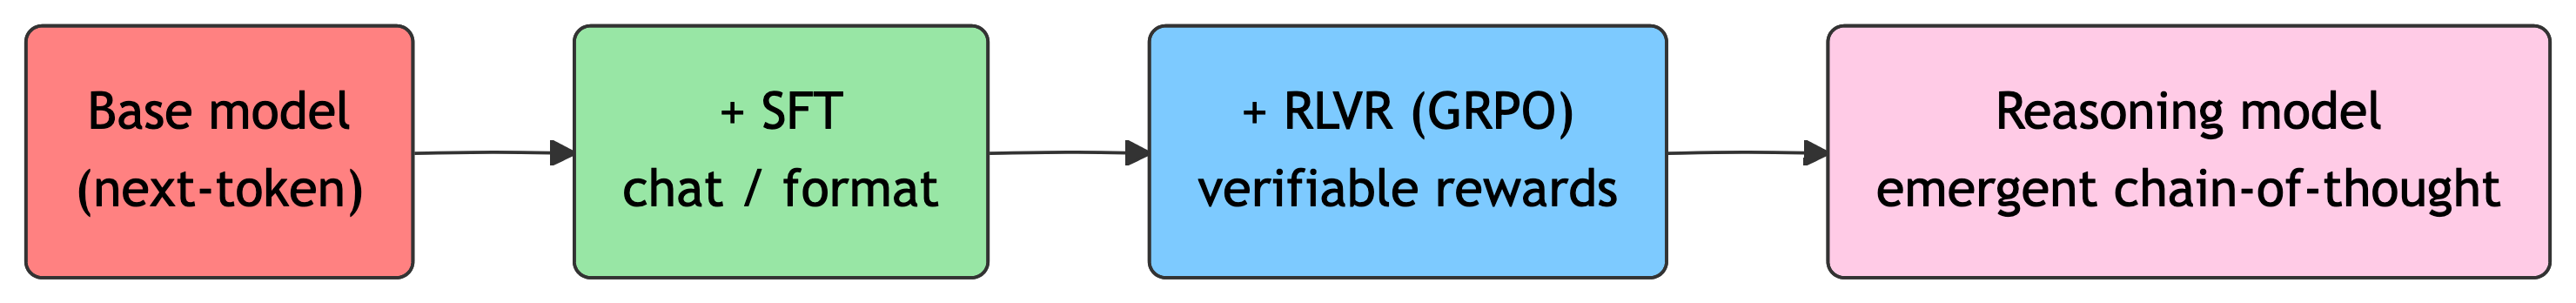
<figcaption>Figure 3: The reasoning-model recipe: <strong>base → SFT →
RLVR</strong>. DeepSeek-R1 showed that RLVR on top of a capable base
model makes long chain-of-thought reasoning <strong>emerge</strong>,
rewarded only by final-answer correctness — no step-by-step supervision
required.</figcaption>
</figure>

> **🔬 At frontier scale…**
>
> DeepSeek-R1 ([arXiv:2501.12948](https://arxiv.org/abs/2501.12948))
> pushes RLVR to its limit. Their **R1-Zero** run applies GRPO *directly
> to the base model* with purely verifiable rewards — no SFT warm-up —
> and watches reasoning behaviors (self-checking, backtracking, and
> steadily **longer** `<think>` traces) appear on their own as accuracy
> climbs. The full **R1** adds a small SFT “cold start” for readability,
> then large-scale GRPO across many nodes with a fast generation backend
> (e.g. vLLM) feeding the training ranks.
>
> The distributed machinery underneath is exactly what you already know
> from [\[1.4\] Distributed
> Training](../../01-neural-networks/4-distributed-training/index.qmd):
> the policy is sharded with ZeRO/FSDP, generation is parallelized
> across ranks, and rewards are gathered with the same collectives. RL
> just adds a **generate → verify → update** loop around the training
> step. The API below is the same one you saw in §①b — only the model
> size, the verifier, and the node count change.

## 🤖 ③ Build an agentic reasoning model

The trick that makes a model *reason* is a **format contract**: force
the model to “think out loud” inside `<think>...</think>` tags
**before** committing to a final answer. During RLVR we only score what
comes **after** `</think>`, so the model is free to use the scratchpad
however it likes — and because longer, more careful reasoning
empirically leads to more correct final answers, the reasoning behavior
is *reinforced* even though we never reward the reasoning directly.

**1. A system/format prompt** that demands the structure:

In [13]:
SYSTEM_PROMPT = (
    "You are a careful problem-solver. Work through the problem step by step "
    "inside <think> </think> tags, then give ONLY the final answer inside "
    "<answer> </answer> tags.\n"
    "Format: <think> your reasoning </think><answer> final answer </answer>"
)

def make_prompt(question: str) -> list[dict]:
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]

**2. Reward functions** that parse the region after `</think>` and check
it — one verifier for **correctness**, one for **format**. This list is
exactly what you’d hand to `GRPOTrainer(reward_funcs=[...])`:

In [14]:
import re

def extract_answer(text: str) -> str | None:
    m = re.search(r"<answer>(.*?)</answer>", text, re.DOTALL)
    return m.group(1).strip() if m else None

def reward_correct(completions, answer, **kwargs):
    """RLVR: +1 if the parsed final answer matches ground truth, else 0."""
    out = []
    for completion, gold in zip(completions, answer):
        pred = extract_answer(completion)
        out.append(1.0 if pred is not None and pred == str(gold) else 0.0)
    return out

def reward_format(completions, **kwargs):
    """Shape the output: small bonus for obeying the <think>/<answer> contract."""
    pattern = r"<think>.*?</think>\s*<answer>.*?</answer>"
    return [0.2 if re.search(pattern, c, re.DOTALL) else 0.0 for c in completions]

**3. A realistic rollout.** Given the prompt
`"If a train travels 60 km in 1.5 hours, what is its average speed in km/h?"`,
a mid-training policy might sample a group like this (only two of $K$
shown):

``` text
# completion 1  -> reward_correct = 1.0, reward_format = 0.2
<think>
Average speed = distance / time. Distance = 60 km, time = 1.5 h.
60 / 1.5 = 40. Units are km/h, which matches the question.
</think>
<answer>40</answer>

# completion 2  -> reward_correct = 0.0, reward_format = 0.2
<think>
Speed is distance times time, so 60 * 1.5 = 90.
</think>
<answer>90</answer>
```

Both obey the format (`+0.2`), but only the first is correct (`+1.0`).
Summed rewards are `1.2` vs `0.2`; after group standardization the
correct rollout gets a **positive** advantage and the wrong one
**negative** — so GRPO raises the probability of the reasoning path that
led to `40` and lowers the other. Repeat over thousands of prompts and
correct-answer-producing reasoning is what survives.

**4. See it happen.** The two reward functions above are
`#| eval: false` (they’d be handed to `GRPOTrainer`), but they’re plain
Python — so we can run them *now* on a sampled group and feed the result
through the **same** `(r - mean) / std` line from the toy in §①a. This
turns the prose above into numbers, on a laptop CPU:

In [15]:
import re
import torch

# The §③ verifiers — real code, just executed here instead of inside GRPOTrainer.
def extract_answer(text):
    m = re.search(r"<answer>(.*?)</answer>", text, re.DOTALL)
    return m.group(1).strip() if m else None

def reward_correct(completions, answer):
    return [1.0 if extract_answer(c) == str(g) else 0.0
            for c, g in zip(completions, answer)]

def reward_format(completions):
    pattern = r"<think>.*?</think>\s*<answer>.*?</answer>"
    return [0.2 if re.search(pattern, c, re.DOTALL) else 0.0 for c in completions]

# One prompt (gold answer "40"); a group of K=4 sampled rollouts.
group = [
    "<think>60 / 1.5 = 40, units km/h.</think><answer>40</answer>",  # right + formatted
    "<think>60 * 1.5 = 90.</think><answer>90</answer>",              # wrong + formatted
    "<think>60/1.5 = 40.</think><answer>40</answer>",                # right + formatted
    "The average speed is 40 km/h.",                                 # right value, NO tags
]
gold = ["40"] * len(group)

# Total reward = sum of the verifiers -> GRPO group-relative advantage.
r = torch.tensor(reward_correct(group, gold)) + torch.tensor(reward_format(group))
adv = (r - r.mean()) / (r.std() + 1e-8)        # identical to §①a

for i, (tot, a) in enumerate(zip(r.tolist(), adv.tolist())):
    print(f"rollout {i}:  reward = {tot:>4.1f}   advantage = {a:+.2f}")

rollout 0:  reward =  1.2   advantage = +0.86
rollout 1:  reward =  0.2   advantage = -0.70
rollout 2:  reward =  1.2   advantage = +0.86
rollout 3:  reward =  0.0   advantage = -1.02

There is the `1.2` vs `0.2` from the text — now computed — and the group
split into **positive** and **negative** advantage. Notice rollout 3 got
the right *value* but skipped the tags: `reward_correct` can’t parse it,
so it scores the **worst** of the group. That is precisely why the
format contract is rewarded — no parseable answer, no credit.

> **Exercise — zero-variance groups**
>
> The §①a toy noted that if every sample in a group gets the **same**
> reward, the advantage is all zeros and nothing updates. Rebuild
> `group` so all four rollouts are **correct *and* formatted**,
> recompute `adv`, and confirm you get zeros — the policy already agrees
> with the group, so there’s nothing to learn from it.
>
> > **💡 Solution**
> >
> > ``` python
> > group = ["<think>60/1.5 = 40.</think><answer>40</answer>"] * 4
> > gold = ["40"] * len(group)
> > r = torch.tensor(reward_correct(group, gold)) + torch.tensor(reward_format(group))
> > adv = (r - r.mean()) / (r.std() + 1e-8)
> > print("advantages:", [round(a, 2) for a in adv.tolist()])  # all 0.0 -> no gradient
> > ```
> >
> >     advantages: [0.0, 0.0, 0.0, 0.0]

<figure id="fig-rlvr-loop">
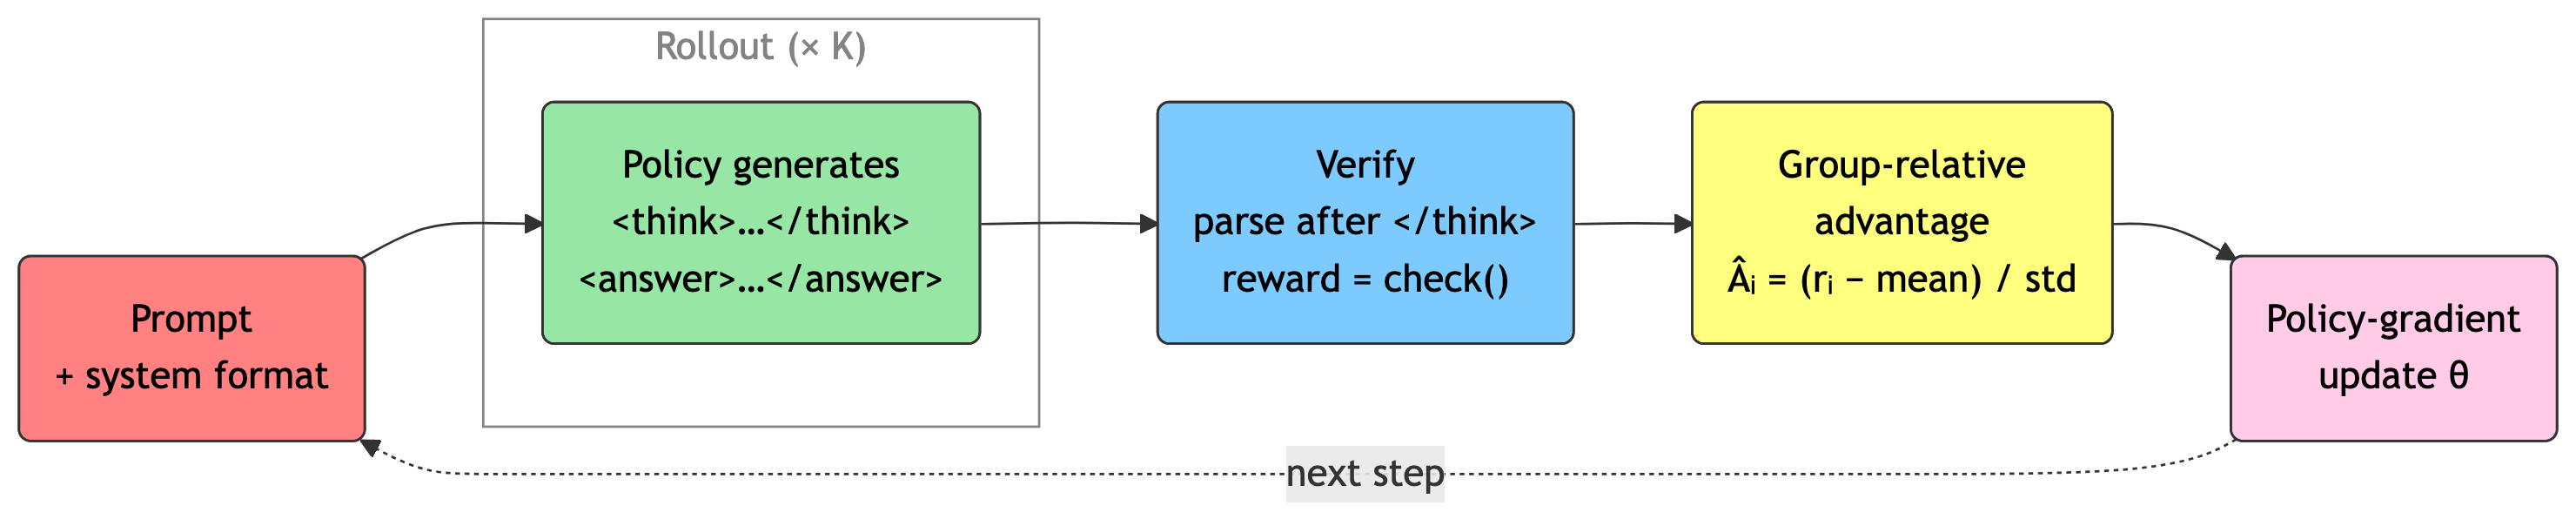
<figcaption>Figure 4: The RLVR reasoning loop. <strong>rollout → verify
→ advantage → update</strong>, repeated. The only human input is the
verifier; the reasoning inside <code>&lt;think&gt;</code> is discovered
by the policy.</figcaption>
</figure>

### 🚀 Scale it up

On the cluster, run GRPO as a plain Python module and let `ezpz` handle
the launch — it auto-detects the scheduler (PBS → `mpiexec`, SLURM →
`srun`) and wires up the distributed environment for you.

1.  Set up the environment and install the RL stack:

    ``` bash
    source <(curl -fsSL https://bit.ly/ezpz-utils) && ezpz_setup_env
    uv pip install git+https://github.com/saforem2/ezpz
    uv pip install "trl>=0.14" "peft>=0.13" "datasets" "accelerate" "vllm"
    ```

2.  Confirm the distributed setup works:

    ``` bash
    ezpz test
    ```

3.  Launch multi-GPU / multi-node GRPO with verifiable rewards.
    `ezpz launch` runs the command across every rank of your allocation:

    ``` bash
    ezpz launch python3 -m trl.scripts.grpo \
        --model_name_or_path Qwen/Qwen2.5-0.5B-Instruct \
        --dataset_name trl-lib/tldr \
        --num_generations 8 \
        --learning_rate 1e-6 \
        --per_device_train_batch_size 8 \
        --max_completion_length 256 \
        --bf16 \
        --use_peft --lora_r 16 --lora_alpha 32 \
        --output_dir grpo-out
    ```

4.  For long runs, add fault tolerance (spare nodes + automatic
    failover):

    ``` bash
    ezpz launch --auto-retry --spare-nodes auto \
        python3 -m trl.scripts.grpo --model_name_or_path Qwen/Qwen2.5-0.5B-Instruct ...
    ```

## 🗳️ Inference-time scaling: self-consistency

Everything above makes a model reason *better by training it*. But
there’s a complementary trick that needs **no training at all** — you
just spend more compute **at inference time**. It’s called
**self-consistency** ([Wang et al. 2022,
arXiv:2203.11171](https://arxiv.org/abs/2203.11171)):

1.  Ask the model the same question **$N$ times** with **sampling on**
    (temperature \> 0, so each run explores a different chain-of-thought
    — see [\[2.5\] Decoding &
    Sampling](../../02-llms/5-decoding-and-sampling/index.qmd)).
2.  Extract the **final answer** from each of the $N$ chains.
3.  Take the **majority vote**.

The intuition: there are many wrong answers but usually one right one,
so *correct* final answers tend to agree with each other while mistakes
scatter. Voting concentrates the signal.

Here’s the whole idea as a runnable toy — no model needed. We simulate a
“reasoner” that lands on the correct answer **45% of the time** (so a
single sample is wrong more often than not) and otherwise blurts a
random wrong answer, then watch what majority-vote accuracy does as we
increase $N$:

In [17]:
import random
from collections import Counter

random.seed(0)
TRUE_ANSWER = 42
P_CORRECT = 0.45            # one sample is right < half the time
WRONG_POOL = [7, 13, 40, 41, 43, 99]

def one_chain():
    """Simulate one sampled chain-of-thought's final answer."""
    if random.random() < P_CORRECT:
        return TRUE_ANSWER
    return random.choice(WRONG_POOL)

def self_consistency_answer(n):
    """Sample n chains, return the majority-voted final answer."""
    votes = Counter(one_chain() for _ in range(n))
    return votes.most_common(1)[0][0]

# Estimate accuracy of majority-vote as N grows (averaged over many trials).
TRIALS = 400
Ns = [1, 3, 5, 9, 15, 25, 41]
acc = [sum(self_consistency_answer(n) == TRUE_ANSWER for _ in range(TRIALS)) / TRIALS
       for n in Ns]
for n, a in zip(Ns, acc):
    print(f"N={n:>2d} samples -> majority-vote accuracy {a:.2f}")

N= 1 samples -> majority-vote accuracy 0.41
N= 3 samples -> majority-vote accuracy 0.55
N= 5 samples -> majority-vote accuracy 0.68
N= 9 samples -> majority-vote accuracy 0.82
N=15 samples -> majority-vote accuracy 0.92
N=25 samples -> majority-vote accuracy 0.99
N=41 samples -> majority-vote accuracy 1.00

A single sample is right ~45% of the time, but voting over a couple
dozen samples pushes accuracy well past that — the correct answer wins
the vote even though it’s a minority of any *individual* run’s mistakes:

In [18]:
import plotly.graph_objects as go
from bootcamp.plotly_theme import apply_theme, COLORS
apply_theme()

fig = go.Figure()
fig.add_scatter(x=Ns, y=acc, mode="lines+markers", name="majority vote",
                line=dict(color=COLORS["green"], width=2), marker=dict(size=8))
fig.add_hline(y=P_CORRECT, line=dict(color=COLORS["grey"], dash="dash"),
              annotation_text="single sample (~0.45)")
fig.update_layout(height=340, margin=dict(t=40),
                  title="More samples → better answers (no extra training)",
                  xaxis_title="N (chains sampled per question)",
                  yaxis_title="accuracy", yaxis_range=[0, 1])
fig.show()

> **🎯 Two ways to buy reasoning**
>
> - **RLVR / GRPO** (above) bakes reasoning *into the weights* — pay
>   once at training time, cheap at inference.
> - **Self-consistency** buys reasoning *at inference time* — no
>   training, but you pay $N\times$ the generation cost per question.
>
> They compose: a GRPO-trained reasoning model sampled with
> self-consistency is a very strong, if compute-hungry, combination.
> This is the “inference-time scaling” that makes reasoning models like
> o1/R1 so effective.

## 🎒 Homework

Train (or prompt-then-train) a small model to use the `<think>` pattern
on a **toy math task** and reward **correct final answers** with RLVR,
then submit *proof* that the reward went up over training.

Your submission should include:

1.  The **system/format prompt** enforcing
    `<think>…</think><answer>…</answer>`, and your **reward
    function(s)** (a correctness verifier, optionally a format reward).
2.  A tiny **dataset of prompts** with ground-truth answers
    (e.g. 100–500 grade-school arithmetic or
    [GSM8K](https://huggingface.co/datasets/openai/gsm8k)-style
    problems).
3.  A **reward-vs-step** curve (or the logged numbers) showing the mean
    reward *increasing* as GRPO trains — this is your proof-of-run.

Where *proof* can be any of:

- The contents printed to your terminal during the run (per-step
  reward).
- A path to a logfile from a run on the ALCF filesystems.
- A screenshot of the reward curve or a sample `<think>` rollout before
  vs. after.
- A url to a [W&B Run](https://wandb.ai) or W&B Report.

> **Hint**
>
> Start from `Qwen/Qwen2.5-0.5B-Instruct` (it already speaks a chat
> template), `GRPOTrainer` with `num_generations=8`, and the two reward
> functions from §③. Keep `max_completion_length` small and use a
> handful of arithmetic prompts so a step takes seconds. Log the mean of
> `reward_correct` each step and watch it climb.

## 📚 References

- Ouyang et al., *Training language models to follow instructions with
  human feedback* (InstructGPT / PPO-RLHF) —
  [arXiv:2203.02155](https://arxiv.org/abs/2203.02155)
- Rafailov et al., *Direct Preference Optimization* (DPO) —
  [arXiv:2305.18290](https://arxiv.org/abs/2305.18290)
- Shao et al., *DeepSeekMath* (introduces GRPO) —
  [arXiv:2402.03300](https://arxiv.org/abs/2402.03300)
- Lambert et al., *Tülu 3: Pushing Frontiers in Open Language Model
  Post-Training* (RLVR) —
  [arXiv:2411.15124](https://arxiv.org/abs/2411.15124)
- DeepSeek-AI, *DeepSeek-R1: Incentivizing Reasoning Capability in LLMs
  via RL* — [arXiv:2501.12948](https://arxiv.org/abs/2501.12948)
- HuggingFace TRL — [GRPO
  Trainer](https://huggingface.co/docs/trl/grpo_trainer) · [DPO
  Trainer](https://huggingface.co/docs/trl/dpo_trainer) · [PPO
  Trainer](https://huggingface.co/docs/trl/ppo_trainer)
- Previous: [\[3.3\] Mid- &
  Post-Training](../3-mid-post-training/index.qmd) — CPT + SFT with
  TRL/PEFT.

Last updated: 2026-08-03 21:58:32